# Customer Segmentation using Hierarchical Clustering

This notebook performs customer segmentation on a dataset of annual income and spending scores.


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Set seed for reproducibility
np.random.seed(42)

In [2]:
# 1. Load Data
data_path = 'data/customer_hierarchical_clustering_1000.csv'
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"Data loaded from {data_path}.")
    print(df.head())
else:
    raise FileNotFoundError(f"Could not find the data file at {data_path}")

Data loaded from data/customer_hierarchical_clustering_1000.csv.
   Annual_Income  Spending_Score
0             43              66
1            188              58
2             98              52
3             40              91
4            148              85


In [3]:
# 2. Data Cleaning
# The data is assumed to be cleaned. We check for missing values here.
if df.isnull().values.any():
    df = df.dropna()
    print("Missing values handled.")
else:
    print("Data cleaning: No missing values found.")

Data cleaning: No missing values found.


In [4]:
# 3. Preprocessing
# We use 'Annual_Income' and 'Spending_Score' as per the CSV structure.
features = ['Annual_Income', 'Spending_Score']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])
print("Data scaled successfully.")

Data scaled successfully.


In [5]:
# 4. Hierarchical Clustering
n_clusters = 4
model = AgglomerativeClustering(n_clusters=n_clusters)
cluster_labels = model.fit_predict(scaled_data)

df['Cluster'] = cluster_labels
print(f"Hierarchical Clustering completed with {n_clusters} clusters.")

Hierarchical Clustering completed with 4 clusters.


In [6]:
# 5. Train KNN for prediction on new data
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(scaled_data, cluster_labels)
print("KNN model trained for prediction functionality.")

KNN model trained for prediction functionality.


In [ ]:
# 6. Exporting models and data
os.makedirs('model', exist_ok=True)

# Package scaler and knn into a single model file
model_package = {
    'scaler': scaler,
    'knn': knn,
    'features': features
}
joblib.dump(model_package, 'model/model.pkl')

df.to_csv('model/segments.csv', index=False)

print("Models (model/model.pkl) and data (model/segments.csv) exported successfully.")

Models (model/model.pkl) and data (model/segments.csv) exported successfully.


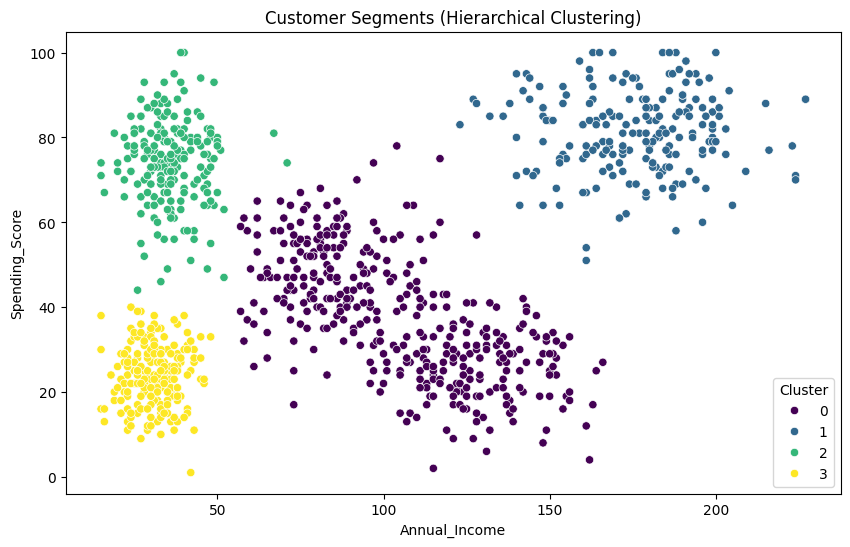

In [8]:
# 7. Visualization of clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score', hue='Cluster', palette='viridis')
plt.title('Customer Segments (Hierarchical Clustering)')
plt.show()